# Step 2 - Dataset Understanding

In this section, I inspect the loan approval dataset to understand:
- target column
- feature types
- class balance
- basic statistics
- possible columns to drop

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
import pandas as pd

df = pd.read_csv("../data/loan_approval_dataset.csv")
print("CSV loaded successfully.")

CSV loaded successfully.


In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
print("Rows, Columns:", df.shape)

Rows, Columns: (4269, 13)


In [7]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [9]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [10]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [13]:
df[" loan_status"].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [6]:
df[" loan_status"].value_counts(normalize=True)

 loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

## Column meanings

- `loan_id` = unique ID for each application
- `no_of_dependents` = number of dependents the applicant supports
- `education` = applicant education level
- `self_employed` = whether the applicant is self-employed
- `income_annum` = annual income
- `loan_amount` = requested loan amount
- `loan_term` = length of loan
- `cibil_score` = credit score
- `residential_assets_value` = value of residential assets
- `commercial_assets_value` = value of commercial assets
- `luxury_assets_value` = value of luxury assets
- `bank_asset_value` = value of bank-held assets
- `loan_status` = final loan decision (target column)

In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
df.describe(include="object")

/var/folders/93/089f0j5140590b91wt26qzwm0000gn/T/ipykernel_18308/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [9]:
print("education:", df[" education"].unique())
print("self_employed:", df[" self_employed"].unique())
print("loan_status:", df[" loan_status"].unique())

education: <StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str
self_employed: <StringArray>
[' No', ' Yes']
Length: 2, dtype: str
loan_status: <StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
missing_values = df.isnull().sum()
print(missing_values)

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [12]:
print("Total missing values in dataset:", missing_values.sum())

Total missing values in dataset: 0


In [14]:
print("Total rows:", len(df))
print("Unique loan_id values:", df["loan_id"].nunique())

Total rows: 4269
Unique loan_id values: 4269


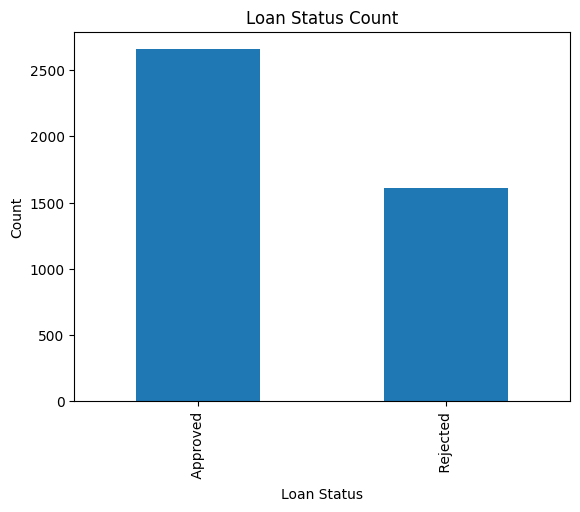

In [16]:
df[" loan_status"].value_counts().plot(kind="bar")
plt.title("Loan Status Count")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

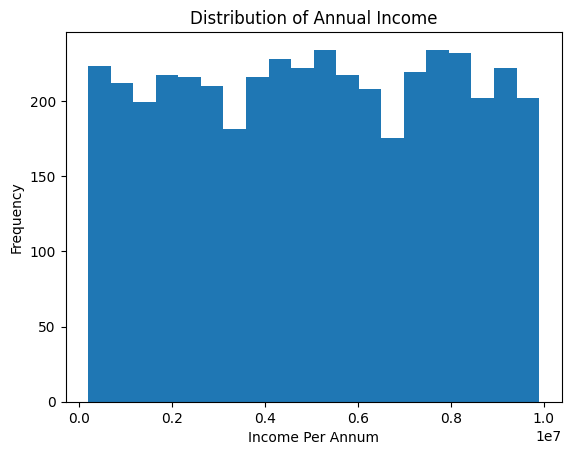

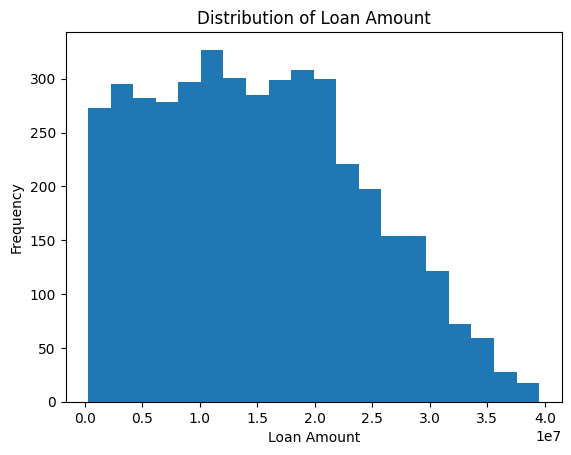

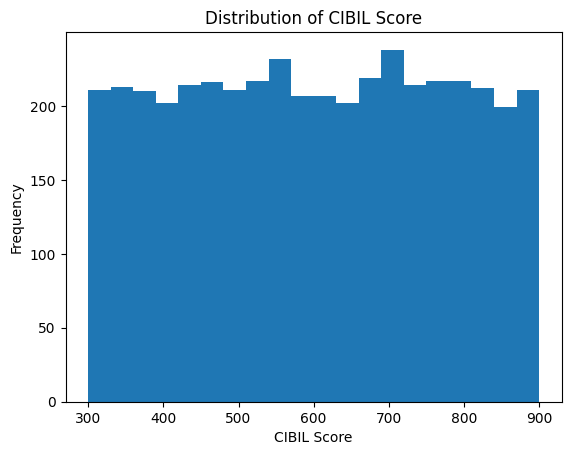

In [17]:
df[" income_annum"].plot(kind="hist", bins=20)
plt.title("Distribution of Annual Income")
plt.xlabel("Income Per Annum")
plt.ylabel("Frequency")
plt.show()

df[" loan_amount"].plot(kind="hist", bins=20)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

df[" cibil_score"].plot(kind="hist", bins=20)
plt.title("Distribution of CIBIL Score")
plt.xlabel("CIBIL Score")
plt.ylabel("Frequency")
plt.show()

In [19]:
df.groupby(" loan_status")[[" income_annum", " loan_amount", " cibil_score", " bank_asset_value"]].mean()

,income_annum,loan_amount,cibil_score,bank_asset_value
loan_status,,,,
Approved,5.025904e+06,1.524725e+07,703.461973,4.959526e+06
Rejected,5.113825e+06,1.494606e+07,429.468072,5.004960e+06


## Step 2 observations

- The target column is ` loan_status`.
- The dataset has 4269 rows and 13 columns.
- There appear to be 10 numeric columns and 3 text columns.
- `loan_id` appears to be an identifier and will likely be dropped before modeling.
- The main categorical columns are `education` and `self_employed`.
- The target classes appear to be: `Approved` and `Rejected`.
- Missing values: 0
- Duplicate rows: 0
- Early signs suggest that columns like `cibil_score`, `income_annum`, and `loan_amount` may be important.